In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import cv2 as cv

(a) NumPy Implementation of 5x5 Gaussian Kernel

In [13]:

def get_gaussian_kernel(size, sigma):
    # Create a coordinate grid centered at 0
    ax = np.linspace(-(size - 1) / 2., (size - 1) / 2., size)
    x, y = np.meshgrid(ax, ax)
    
    # Calculate Gaussian values
    kernel = np.exp(-0.5 * (np.square(x) + np.square(y)) / np.square(sigma))
    
    # Normalize so the sum of all elements is 1
    return kernel / np.sum(kernel)

kernel_5x5 = get_gaussian_kernel(5, 2)
print("5x5 Gaussian Kernel (sigma=2):\n", kernel_5x5)

5x5 Gaussian Kernel (sigma=2):
 [[0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.03832756 0.05576627 0.06319146 0.05576627 0.03832756]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]]


(b) 3D Surface Plot Visualization

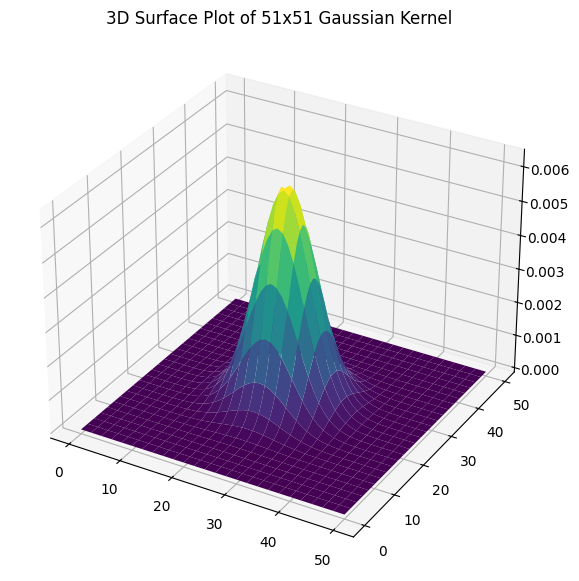

In [ ]:
# Compute 51x51 kernel
kernel_51 = get_gaussian_kernel(51, 5)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

X = np.arange(0, 51)
Y = np.arange(0, 51)
X, Y = np.meshgrid(X, Y)

surf = ax.plot_surface(X, Y, kernel_51, cmap='viridis')
ax.set_title("3D Surface Plot of 51x51 Gaussian Kernel")
plt.show()

(c) Manual Smoothing vs (d) OpenCV Built-in

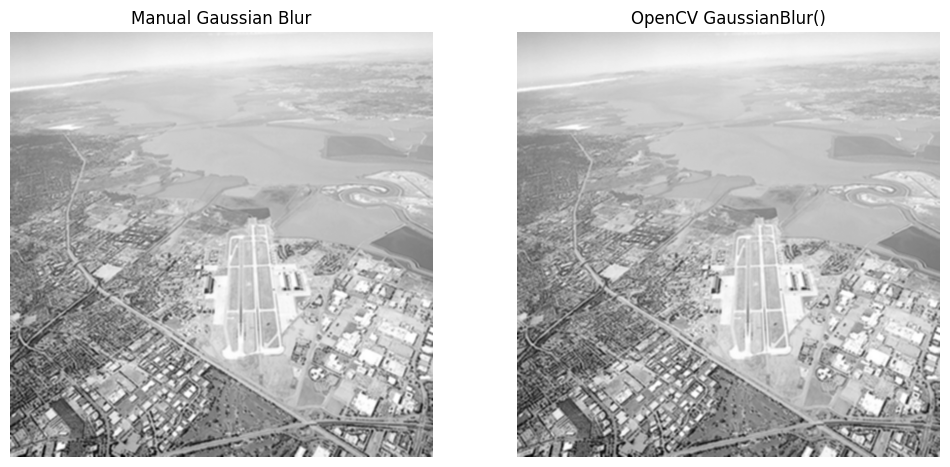

In [ ]:
# --- (c) Manual Smoothing Function ---
def manual_convolve2d(image, kernel):
    h, w = image.shape
    kh, kw = kernel.shape
    pad = kh // 2
    
    # Using 'reflect' mode prevents dark borders
    padded = np.pad(image, pad, mode='reflect')
    output = np.zeros_like(image, dtype=float)

    for i in range(h):
        for j in range(w):
            region = padded[i:i+kh, j:j+kw]
            output[i, j] = np.sum(region * kernel)

    return np.clip(output, 0, 255).astype(np.uint8)

# Load image
img = cv.imread('runway.png', cv.IMREAD_GRAYSCALE)

img_manual = manual_convolve2d(img, kernel_5x5)
cv.imwrite('results/ques5/manual_gaussian_blur_output.png', img_manual)

# --- (d) OpenCV Built-in Smoothing ---
img_opencv = cv.GaussianBlur(img, (5, 5), 2)
cv.imwrite('results/ques5/openCV_gaussian_blur_output.png', img_opencv)

# --- Comparison ---
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img_manual, cmap='gray')
plt.title("Manual Gaussian Blur")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_opencv, cmap='gray')
plt.title("OpenCV GaussianBlur()")
plt.axis('off')
plt.show()